# Conditioning study

This notebook intends to clarify the core issues with the conditioning of the discrete wave equation operator to inform a preconditioning approach.

## Setup

The `WaveEquation` class exposes `matvec` and `rmatvec` to enact the behaviour of the full wave equation operator $A$, such that

$$Au = s,$$

without ever fully assembling $A$, for the sake of memory. For ground truth diagnostics on small grids we should materialise $A$ by appling `matvec` operations to each unit column.

In [1]:
import numpy as np

from odil_wave.grid import Grid
from odil_wave.wavefield import Wavefield
from odil_wave.models.velocity_models import HomogeneousModel
from odil_wave.operator.utils import WaveEquation

In [2]:
def make_problem(nx=8, ny=8, t_max=0.5, cfl_safety=0.8, background_c=1.0, time_order=2, space_order=2):
    grid  = Grid(nx=nx, ny=ny, t_max=t_max, cfl_safety=cfl_safety, c_ref=background_c)

    model = HomogeneousModel(grid, background_c=background_c)
    we = WaveEquation(Wavefield(grid), model, time_order=time_order, space_order=space_order)
    N = grid.nt * grid.nx * grid.ny

    return grid, model, we, N

def materialise(matvec, N):
    """Dense A via A[:, j] = matvec(e_j)."""
    A = np.empty((N, N))
    e = np.zeros(N)

    for j in range(N):
        e[j] = 1.0
        A[:, j] = matvec(e)
        e[j] = 0.0
    return A


In [3]:
grid, model, wave_eq, N = make_problem()

In [4]:
A = materialise(wave_eq.matvec, N)

Before proceeding, we should check that the materialised `A` really is the operator. We can do so by comparing `A @ u` to `wave_eq.matvec(u)` for some random vector `u`.

In [5]:
u = np.random.default_rng(0).standard_normal(N)
allclose = np.allclose(A @ u, wave_eq.matvec(u))

print("Materialised A is the proper operator:", allclose)

Materialised A is the proper operator: True


## Experiment 1: investigating the reference operator's conditioning

A row of $A$ is one equation (one residual component $r_i = (Au - s)_i$). Its $L_2$ norm is the magnitude of the coefficients in the equation. Interior PDE rows, IC rows, and Higdon BC rows are 3 different operators, so they have different magnitudes.

A column of $A$ is one unknown. Column $j$ tells us how strongly $u_j$ (the field at one space time point) appears across all equations. Its norm can be thought of as the sensitivity of the system to that unknown.

The [Van der Sluis theorem](https://user.it.uu.se/~maney676/Courses/NLA/Projects/2014/VanderSluis1963.pdf) is what motivates row/column scaling. This work looks at equillibration: choosing diagonal matrices $D_r$ and $D_c$ so a scaled matrix $D_r A D_c$ has balanced rows and columns. The work showed that this kind of scaling cannot make the conditioning number of the matrix worse, and that the equilibriated matrix can be within a factor of n of the best possible conditioning number.

Thus, if we look at the norms of the rows and columns of our operator, then the row norm spread tells us how much of the conditioning number of $A$ is removable by left diagonal scaling (row preconditioning) and the column norm spread says how much is removable by right scaling (Jacobi/ column preconditioning).

First, let's compute the row and column norms of the operator.

In [6]:
row = np.linalg.norm(A, axis=1)
col = np.linalg.norm(A, axis=0)
print("row norm spread:", row.max() / row[row > 0].min())
print("col norm spread:", col.max() / col[col > 0].min())

row norm spread: 2.6457513110645907
col norm spread: 2.6575364531836625


Next, we can look at what the worst rows are (those with the highest norm).

In [7]:
nsp = grid.nx * grid.ny
worst = np.argsort(row)[-10:] # get the indices of the rows with the largest norms

worst_rows = [(r // nsp, r % nsp) for r in worst]

print("Worst rows (t, spatial):", )
for i in range(len(worst_rows) - 1):
    print(worst_rows[i])

Worst rows (t, spatial):
(np.int64(2), np.int64(15))
(np.int64(2), np.int64(8))
(np.int64(2), np.int64(7))
(np.int64(2), np.int64(6))
(np.int64(2), np.int64(5))
(np.int64(2), np.int64(4))
(np.int64(2), np.int64(3))
(np.int64(2), np.int64(2))
(np.int64(2), np.int64(1))


The conditioning number of a matrix is the ratio of its largest and smallest singular values. This we can compute a singular value decomposition of the operator matrix to compute its conditioning number $\text{cond}(A)$. In the Gauss Newton method, we expose options to solve using `lsqr` (least squares) and `cg` (conjugate gradient). CG sees $\text{cond}(A^TA) = \text{cond}(A)^2$, so we will compute that too to see the penalty we avoid by not forming $A^T A$ (i.e., not using `cg`).

In [8]:
from scipy.linalg import svd

In [9]:
s = svd(A, compute_uv=False)

condA = s[0] / s[-1]

print(f"cond(A) = {condA:.3e}")
print(f"cond(AtA) = {condA**2:.3e}")

cond(A) = 1.112e+03
cond(AtA) = 1.237e+06


Ok, the conditioning number is large already, so using $A^T A$ is catastrophic.

We can look at the distribution of the singular values too.

In [10]:
import matplotlib.pyplot as plt

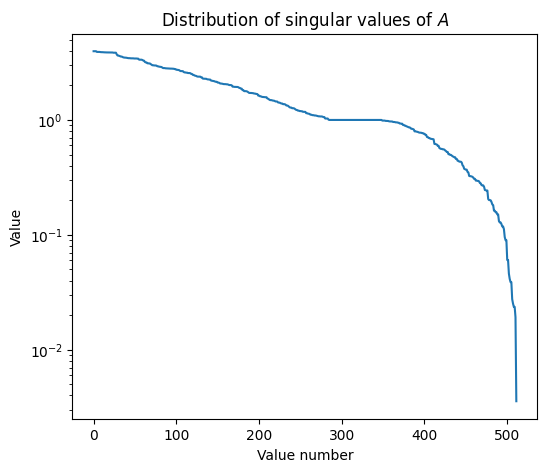

In [11]:
fig, ax = plt.subplots(figsize=(6, 5))
ax.semilogy(s)
ax.set_title(r"Distribution of singular values of $A$")
ax.set_ylabel("Value")
ax.set_xlabel("Value number")
plt.show()

This is quite informative. Singular values measure the magnitude of a matrix's action along orthogonal directions. In our wave equation context, the large singular values tell use directions that the operator transmits strongly, and vice versa for small values. The large distribution in values suggests that our system is strongly ill conditioned and that the ill conditioning is not concentrated to a few isolated valyes. 

Let's look at how $\text{cond}(A)$ changes with the grid.

In [12]:
def cond_of(nx, ny, t_max=0.5, cfl_safety=0.8):
    grid, model, we, N = make_problem(nx=nx, ny=ny, t_max=t_max, cfl_safety=cfl_safety)
    A = materialise(we.matvec, N)

    return dict(nx=nx, N=N, nt=grid.nt, h=grid.dx, cfl=grid.cfl(model.c_max), cond=np.linalg.cond(A))

In [13]:
import math

def t_max_for_nt(nx, nt_target, cfl_safety=0.8, c_ref=1.5):
    """t_max that yields ~nt_target steps at given nx on the unit square."""
    dx = 1.0 / (nx - 1)
    dt_cfl = dx / (c_ref * math.sqrt(2.0)) # = 1 / (c_ref*sqrt(1/dx^2+1/dy^2))
    return (nt_target - 1) * cfl_safety * dt_cfl * (1 - 1e-9)  # shave for ceil

In [14]:
NT = 10
rowsA = [cond_of(n, n, t_max=t_max_for_nt(n, NT)) for n in [6, 8, 10, 12, 14, 16]]

In [15]:
for r in rowsA:
    print(f"n={r['nx']:2d}, N={r['N']:5d}, nt={r['nt']:2d}, h={r['h']:.4f}, CFL={r['cfl']:.3f}, cond={r['cond']:.3e}")

n= 6, N=  252, nt= 7, h=0.2000, CFL=0.800, cond=2.100e+02
n= 8, N=  448, nt= 7, h=0.1429, CFL=0.800, cond=5.005e+02
n=10, N=  700, nt= 7, h=0.1111, CFL=0.800, cond=2.142e+03
n=12, N= 1008, nt= 7, h=0.0909, CFL=0.800, cond=1.585e+03
n=14, N= 1372, nt= 7, h=0.0769, CFL=0.800, cond=3.692e+03
n=16, N= 1792, nt= 7, h=0.0667, CFL=0.800, cond=1.337e+03


cond ~ dx^(-2.14)


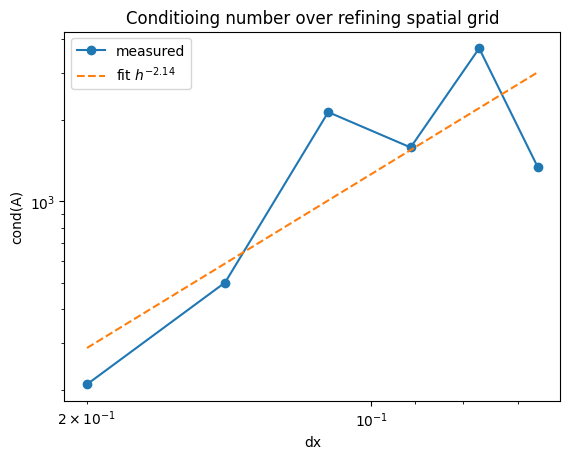

In [16]:
h = np.array([r["h"] for r in rowsA])
cond = np.array([r["cond"] for r in rowsA])
q, logc = np.polyfit(np.log(h), np.log(cond), 1)
print(f"cond ~ dx^({q:.2f})")

plt.loglog(h, cond, "o-", label="measured")
plt.loglog(h, np.exp(logc) * h**q, "--", label=f"fit $h^{{{q:.2f}}}$")
plt.gca().invert_xaxis()              # refinement goes left to right
plt.xlabel("dx")
plt.ylabel("cond(A)") 
plt.title("Conditioing number over refining spatial grid")
plt.legend()
plt.show()

In [17]:
rowsB = [cond_of(5, 5, t_max=T) for T in [0.2,0.3,0.4,0.5,0.7,1.0,1.4,2.0,3.0,5.0,10.0,25.0]]

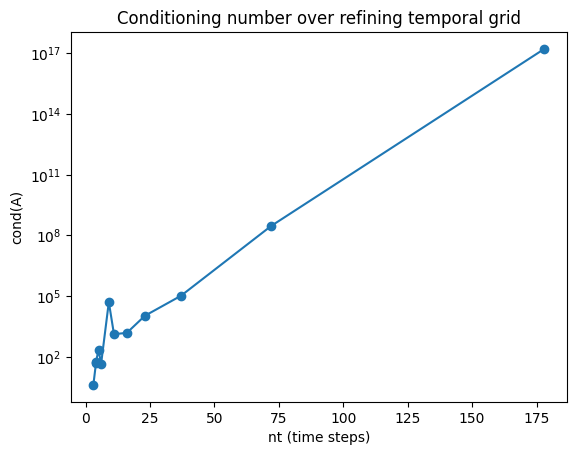

In [18]:
nt = [r["nt"] for r in rowsB]
cond = [r["cond"] for r in rowsB]

plt.semilogy(nt, cond, "o-")
plt.xlabel("nt (time steps)")
plt.ylabel("cond(A)")
plt.title("Conditioning number over refining temporal grid")
plt.show()

Let's also separate out the minimum and maximum singular values and see how they behave with varying `nt`.

In [19]:
def spectrum_of(nx, ny, **kw):
    grid, model, we, N = make_problem(nx=nx, ny=ny, **kw)
    s = np.linalg.svd(materialise(we.matvec, N), compute_uv=False)
    return grid.nt, s[0], s[-1]

data = [spectrum_of(5, 5, t_max=T) for T in [0.2,0.3,0.4,0.5,0.7,1.0,1.4,2.0,3.0,5.0,10.0]]

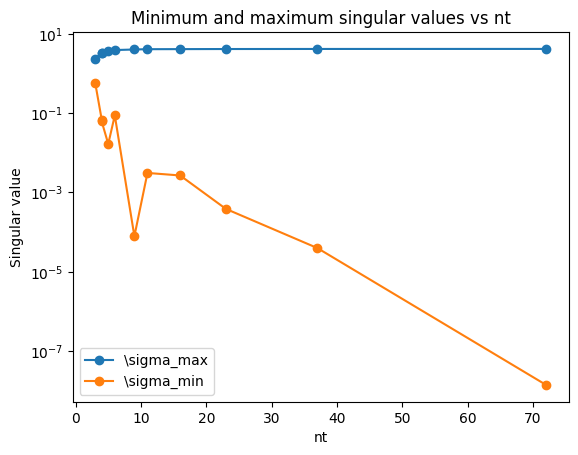

In [20]:
nt, smax, smin = map(np.array, zip(*data))
plt.semilogy(nt, smax, "o-", label=r"\sigma_max"); 
plt.semilogy(nt, smin, "o-", label=r"\sigma_min")
plt.ylabel("Singular value")
plt.xlabel("nt")
plt.title("Minimum and maximum singular values vs nt")
plt.legend()
plt.show()

This is very interesting. We have seen that the conditioning number grows with `nt`, and the above plot is telling us that it is the smallest singular values which are driving this increase. They decrease with `nt`, so $\sigma_\text{max} / \sigma_\text{min}$ (conditioning number) becomes huge.

## Summary

This investigation has been veru informative, and essentially has told us exactly what is ill conditioned.

1. It is not a scaling problem: row/col spread is fairly even
2. Not $\sigma_\text{max}$: roughly stable over time
3. Spatial resolution is secondary driver: `nt` dominates

The thing driving the ill conditioning is $\sigma_\text{min}$, the components of the system corresponding to the smallest singular values. It grows with `nt` in a superlinear fashion. This suggests a *time-structured preconditioner* would be most beneficial for our problem, not a multigrid approach.